In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# Set plotting parameters for figures
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

In [13]:
# Import catrace functions and load dataset configuration
from catrace.exp_collection import read_df
from catrace.dataset import load_dataset_config
dsconfig = load_dataset_config('../dataset_configs/juvenile_dataset_OB_t7.json')

In [14]:
dsconfig.exp_list

[('2021-07-15-DpOBEM-N2_OB', 'naive'),
 ('2021-07-16-DpOBEM-N3_OB', 'naive'),
 ('2021-12-10-DpOBEM-N4_OB', 'naive'),
 ('2021-12-31-DpOBEM-N7_OB', 'naive'),
 ('2022-02-13-DpOBEM-N10_OB', 'naive'),
 ('2022-02-20-DpOBEM-N11_OB', 'naive'),
 ('2021-02-05-DpOBEM-JH9_OB', 'phe-arg'),
 ('2021-03-18-DpOBEM-JH10_OB', 'phe-arg'),
 ('2021-03-19-DpOBEM-JH10_OB', 'phe-arg'),
 ('2021-04-02-DpOBEM-JH11_OB', 'phe-arg'),
 ('2021-04-03-DpOBEM-JH11_OB', 'phe-arg'),
 ('2021-05-01-DpOBEM-JH13_OB', 'phe-arg'),
 ('2021-05-22-DpOBEM-JH14_OB', 'phe-arg'),
 ('2021-09-15-DpOBEM-JH20_OB', 'phe-arg'),
 ('2021-09-17-DpOBEM-JH20_OB', 'phe-arg'),
 ('2021-09-18-DpOBEM-JH20_OB', 'phe-arg'),
 ('2021-07-30-DpOBEM-JH17_OB', 'arg-phe'),
 ('2021-07-31-DpOBEM-JH17_OB', 'arg-phe'),
 ('2021-09-02-DpOBEM-JH18_OB', 'arg-phe'),
 ('2021-09-03-DpOBEM-JH18_OB', 'arg-phe'),
 ('2021-09-04-DpOBEM-JH18_OB', 'arg-phe'),
 ('2021-09-29-DpOBEM-JH21_OB', 'arg-phe'),
 ('2021-10-01-DpOBEM-JH21_OB', 'arg-phe'),
 ('2021-10-02-DpOBEM-JH21_OB', 'ar

In [15]:
from catrace.exp_collection import concatenate_df_from_db
all_dff = concatenate_df_from_db(dsconfig.processed_trace_dir, dsconfig.exp_list)


2021-07-15-DpOBEM-N2_OB None
2021-07-16-DpOBEM-N3_OB None
2021-12-10-DpOBEM-N4_OB None
2021-12-31-DpOBEM-N7_OB None
2022-02-13-DpOBEM-N10_OB None
2022-02-20-DpOBEM-N11_OB None
2021-02-05-DpOBEM-JH9_OB None
2021-03-18-DpOBEM-JH10_OB None
2021-03-19-DpOBEM-JH10_OB None
2021-04-02-DpOBEM-JH11_OB None
2021-04-03-DpOBEM-JH11_OB None
2021-05-01-DpOBEM-JH13_OB None
2021-05-22-DpOBEM-JH14_OB None
2021-09-15-DpOBEM-JH20_OB None
2021-09-17-DpOBEM-JH20_OB None
2021-09-18-DpOBEM-JH20_OB None
2021-07-30-DpOBEM-JH17_OB None
2021-07-31-DpOBEM-JH17_OB None
2021-09-02-DpOBEM-JH18_OB None
2021-09-03-DpOBEM-JH18_OB None
2021-09-04-DpOBEM-JH18_OB None
2021-09-29-DpOBEM-JH21_OB None
2021-10-01-DpOBEM-JH21_OB None
2021-10-02-DpOBEM-JH21_OB None
2021-10-14-DpOBEM-JH22_OB None
2021-11-10-DpOBEM-JH23_OB None
2021-11-11-DpOBEM-JH23_OB None
2021-11-14-DpOBEM-JH23_OB None
2021-11-24-DpOBEM-JH24_OB None
2021-11-27-DpOBEM-JH24_OB None
2021-11-26-DpOBEM-JH24_OB None


In [16]:
dffs = {cond: all_dff.T.xs(cond, level='condition').T for cond in dsconfig.conditions}

In [17]:
# Select some neurons that are responsive to both odors
cut_time = 2.3 # The traces showed be shifted to the left by 2.3s, so that the odor onset is approximately 2s
cut_frame = int(cut_time * dsconfig.frame_rate)
total_time = 10 # Total time to plot, 10s
total_frame = int(total_time * dsconfig.frame_rate)
frame_range = (cut_frame, cut_frame + total_frame) # Frame range to select from the saved firing rate dataframe

# Select the frames
from catrace.process_time_trace import select_time_points
dffs = {cond: select_time_points(dff, frame_range)
        for cond, dff in dffs.items()}

# Select odors
from catrace.process_time_trace import select_odors_df
selected_odors = ['Arg', 'Phe', 'Trp', 'TDCA']
dffs = {cond: select_odors_df(dff, selected_odors)
        for cond, dff in dffs.items()}

0


C:\Users\hubob\AppData\Local\Temp\ipykernel_33456\1120907866.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_response = dff_response.groupby('odor').mean()


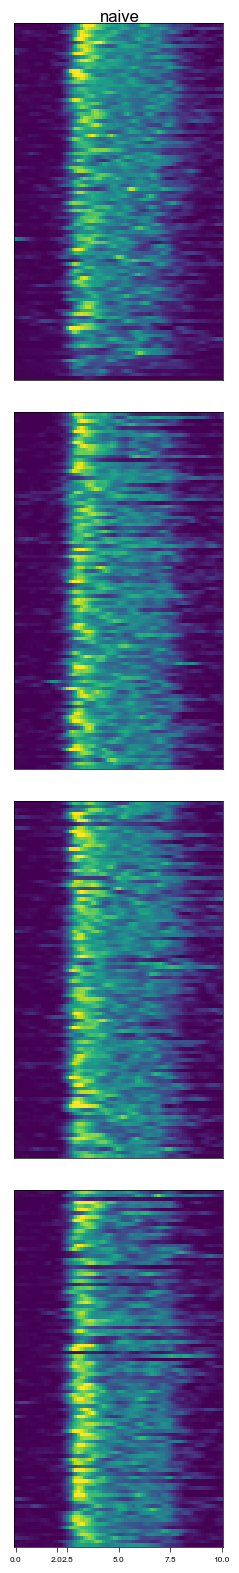

0


C:\Users\hubob\AppData\Local\Temp\ipykernel_33456\1120907866.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_response = dff_response.groupby('odor').mean()


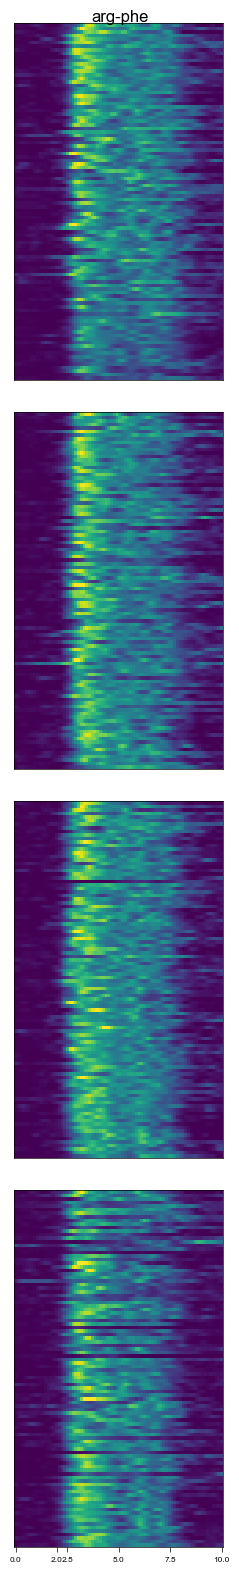

5


C:\Users\hubob\AppData\Local\Temp\ipykernel_33456\1120907866.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_response = dff_response.groupby('odor').mean()


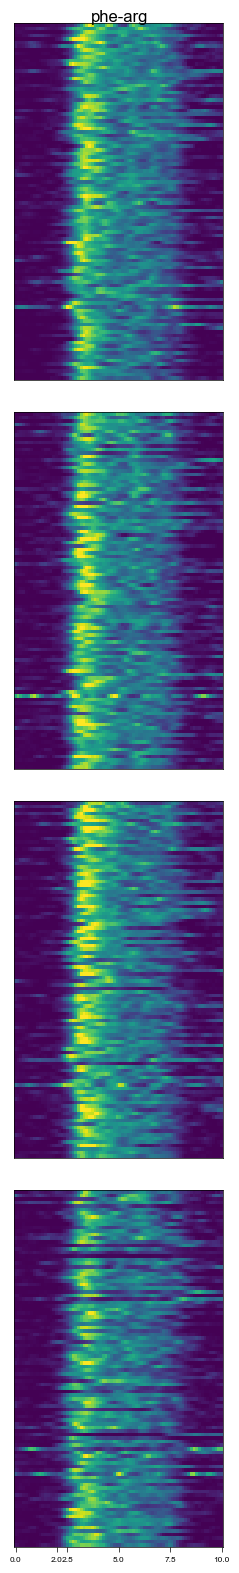

0


C:\Users\hubob\AppData\Local\Temp\ipykernel_33456\1120907866.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_response = dff_response.groupby('odor').mean()


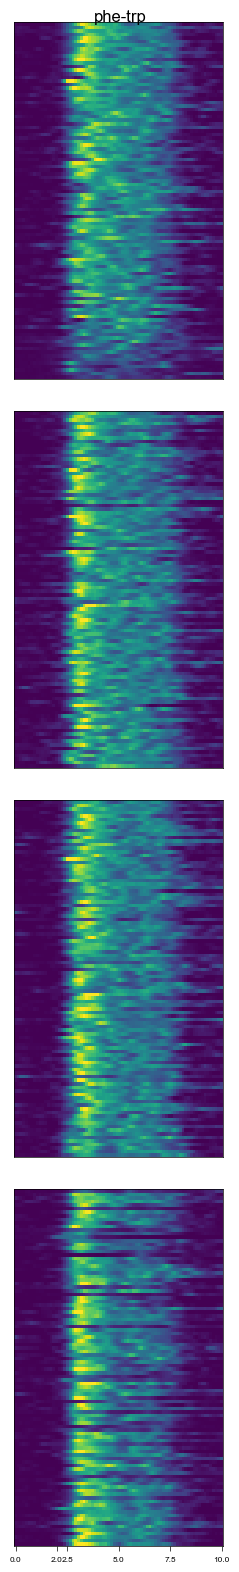

0


C:\Users\hubob\AppData\Local\Temp\ipykernel_33456\1120907866.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_response = dff_response.groupby('odor').mean()


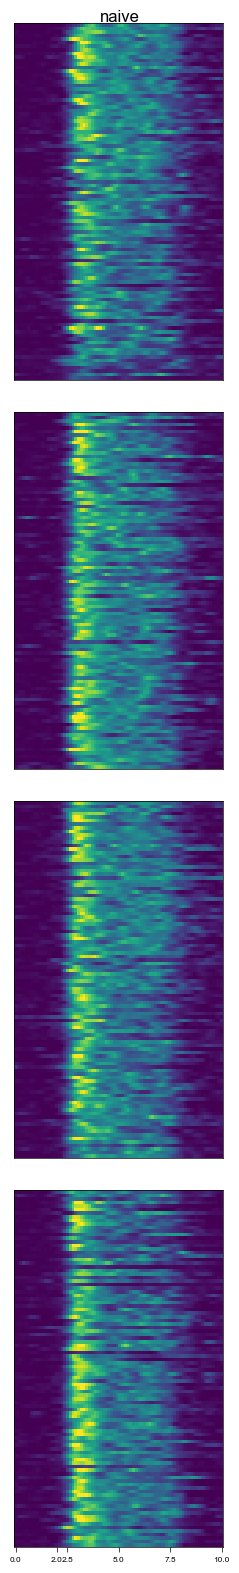

0


C:\Users\hubob\AppData\Local\Temp\ipykernel_33456\1120907866.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_response = dff_response.groupby('odor').mean()


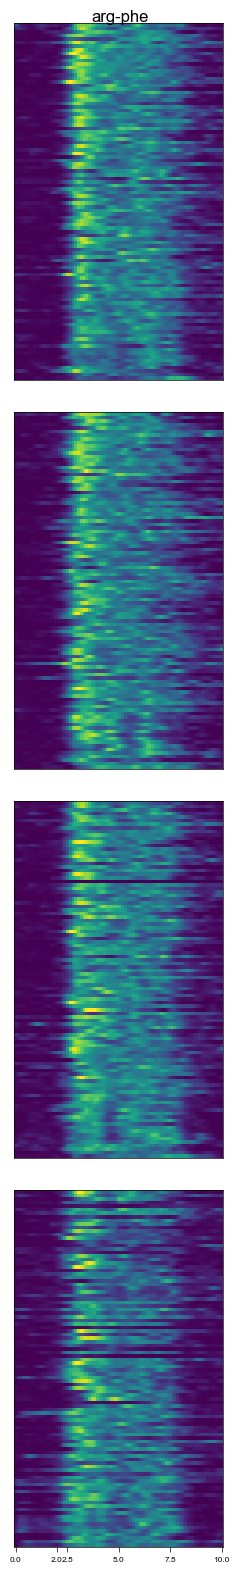

5


C:\Users\hubob\AppData\Local\Temp\ipykernel_33456\1120907866.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_response = dff_response.groupby('odor').mean()


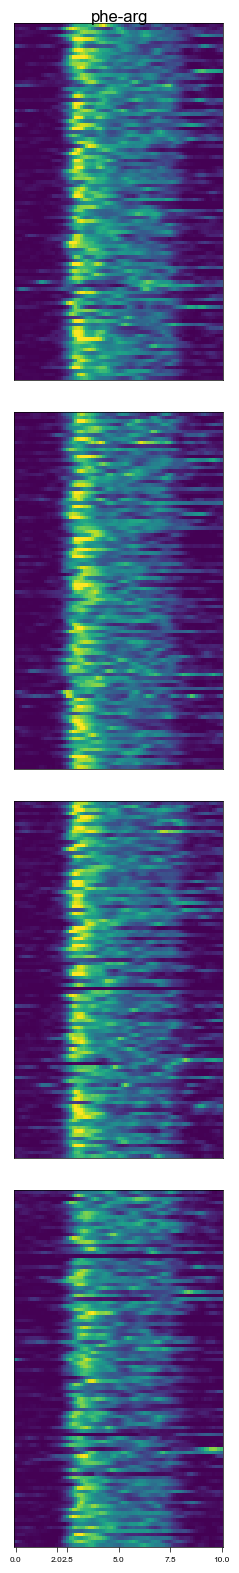

0


C:\Users\hubob\AppData\Local\Temp\ipykernel_33456\1120907866.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_response = dff_response.groupby('odor').mean()


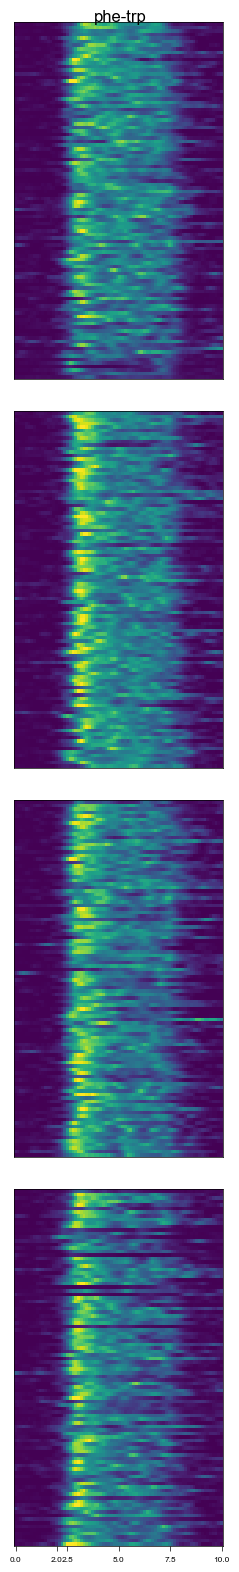

0


C:\Users\hubob\AppData\Local\Temp\ipykernel_33456\1120907866.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_response = dff_response.groupby('odor').mean()


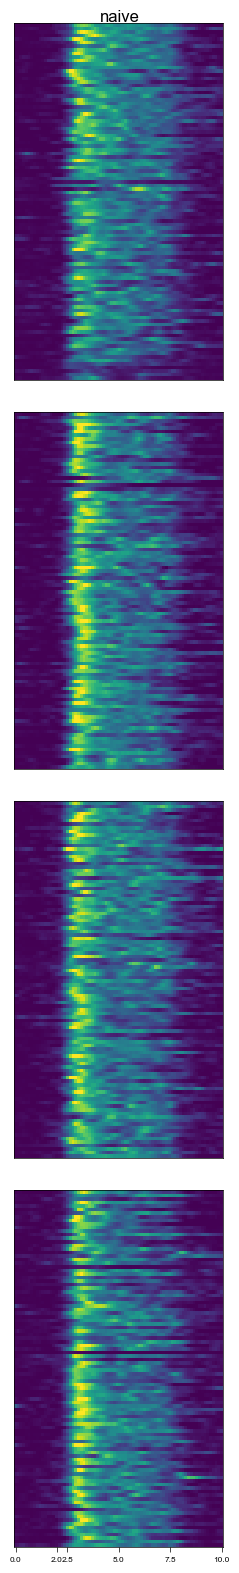

0


C:\Users\hubob\AppData\Local\Temp\ipykernel_33456\1120907866.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_response = dff_response.groupby('odor').mean()


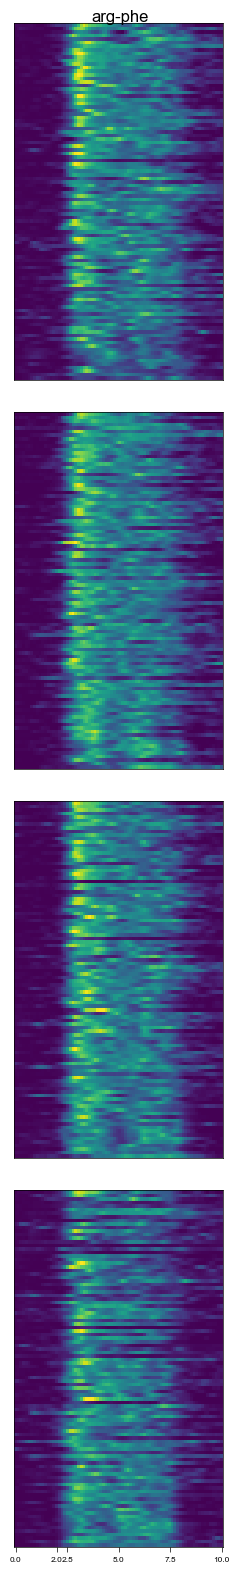

5


C:\Users\hubob\AppData\Local\Temp\ipykernel_33456\1120907866.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_response = dff_response.groupby('odor').mean()


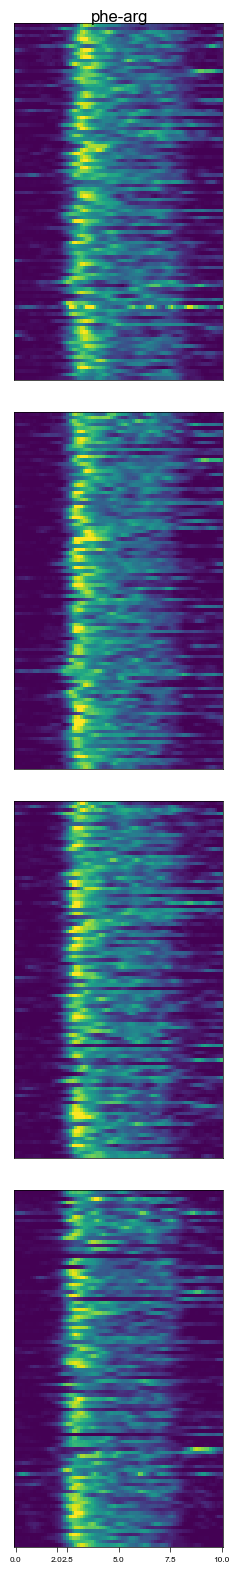

0


C:\Users\hubob\AppData\Local\Temp\ipykernel_33456\1120907866.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_response = dff_response.groupby('odor').mean()


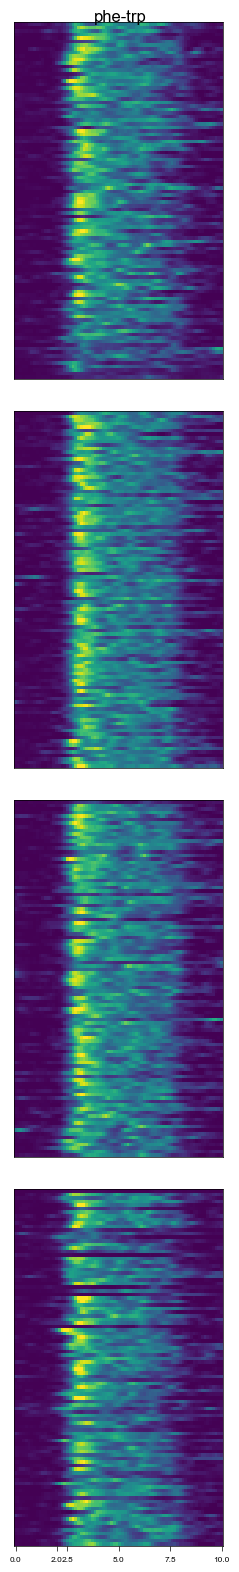

In [26]:
import matplotlib.pyplot as plt
from catrace.plot_trace import plot_example_trace_heatmap
def plot_selected_odors_heatmap(dff, num_neurons, idxs2=None, discard_first_n_neurons=0):
    response_frame_range = (38, 76)
    dff_response = select_time_points(dff, response_frame_range)
    mean_response = dff_response.groupby('odor').mean()
    response_median = mean_response.median()
    if idxs2 is None:
        if discard_first_n_neurons > 0:
            idxs = response_median.sort_values(ascending=False).head(num_neurons+discard_first_n_neurons).index
        else:
            idxs = response_median.sort_values(ascending=False).head(num_neurons).index

        # Sub dataframe selected by top 200 responsive neurons
        mean_response_sub = mean_response.loc[:, idxs]
        # Sort again by response to Arg
        idxs2 = mean_response_sub.loc['Arg'].sort_values(ascending=False).index
        # Remove the first discard_first_n_neurons neurons
        idxs2 = idxs2[discard_first_n_neurons:]

    dff_selected_and_sorted = dff.loc[:, idxs2]
    dff_selected_and_sorted

    # Now plot heatmap for each odor
    # Create subplots with one column, len(selected_odors) rows
    num_selected_odors = len(selected_odors)
    fig, axes = plt.subplots(num_selected_odors, 1, figsize=(2.5, 4*num_selected_odors), sharex=True)
    for idx, odor in enumerate(selected_odors):
        plot_example_trace_heatmap(dff_selected_and_sorted.xs(odor, level='odor').T, dsconfig.frame_rate, gamma=1, vmin=0, vmax=20, ax=axes[idx])
    for ax in axes[:-1]:
        ax.tick_params(bottom=False, labelbottom=False)

    axes[-1].tick_params(labelsize=6)

    return fig, idxs2


# Save figure
import os
from catrace.for_paper import save_figure_for_paper
paper_fig_dir = '../../figures_for_paper/juvenile_ob/example_trace'
os.makedirs(paper_fig_dir, exist_ok=True)

num_neurons = 100  # Number of neurons to plot

idxs2_dict = {}
for trial_number in range(dsconfig.num_trials):
    # Select trials
    dffs_trial = {cond: dff.xs(trial_number, level='trial')
            for cond, dff in dffs.items()}
    for cond, dff in dffs_trial.items():
        if cond == 'phe-arg':
            discard_first_n_neurons = 5
        else:
            discard_first_n_neurons = 0
        print(discard_first_n_neurons)
        if trial_number == 0:
            fig, idxs2 = plot_selected_odors_heatmap(dff, num_neurons=num_neurons, discard_first_n_neurons=discard_first_n_neurons)
            idxs2_dict[cond] = idxs2
        else:
            fig, _ = plot_selected_odors_heatmap(dff, num_neurons=num_neurons, idxs2=idxs2_dict[cond])
        fig.suptitle(cond)
        fig.tight_layout()
        # Make the vertical space between subplots a bit larger
        fig.subplots_adjust(hspace=0.09)
        save_figure_for_paper(fig, f'firing_rate_heatmap_condition_{cond}_num_neurons_{num_neurons}_trial{trial_number}', paper_fig_dir)
        plt.show()